# FER IMPLEMENTATION — Condition 2: Data Augmentation

Ablation condition: **data-level intervention only**.

## Import modules

In [29]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [30]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import keras_tuner as kt
from tensorflow.keras.regularizers import l2

## Dataset paths

In [31]:
# Getting the path to the original train and test directories
train_dir = '/home/kamatsac/Desktop/Thesis/archive/train'
test_dir = '/home/kamatsac/Desktop/Thesis/archive/test'

## Class distribution

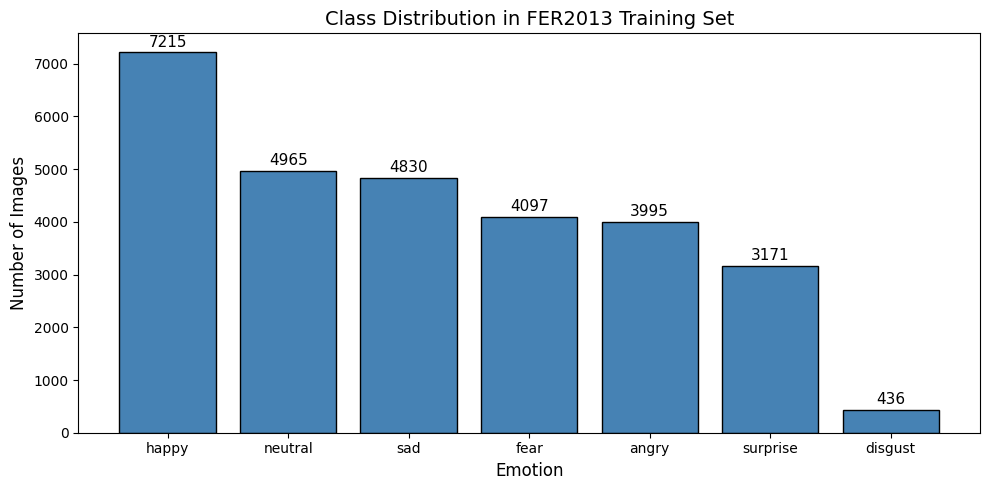

happy: 7215 images
neutral: 4965 images
sad: 4830 images
fear: 4097 images
angry: 3995 images
surprise: 3171 images
disgust: 436 images


In [32]:
classes = os.listdir(train_dir)
class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in classes}
class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontsize=11)
plt.title('Class Distribution in FER2013 Training Set', fontsize=14)
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.tight_layout()
plt.show()

for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

## Load frozen hyperparameters

These were tuned once on the baseline. They are not re-tuned here — that would confound the ablation.

In [33]:
# Load best_hp.json saved at the end of the baseline notebook
# Upload best_hp.json as a Kaggle dataset and update the path below
with open('/home/kamatsac/Desktop/Thesis/best_hp.json') as f: 
    hp_values = json.load(f)

print('Loaded hyperparameters:')
print(f"  Dense units:   {hp_values['dense_units']}")
print(f"  Dropout rate:  {hp_values['dropout_rate']}")
print(f"  Learning rate: {hp_values['learning_rate']}")
print(f"  L2 regularization rate: {hp_values['l2_reg']}")

Loaded hyperparameters:
  Dense units:   256
  Dropout rate:  0.4
  Learning rate: 0.0001
  L2 regularization rate: 1e-05


## Preprocessing

**Key difference from baseline:** Training uses a `TargetedAugSequence` that applies
augmentation **only to minority classes** (disgust, surprise).  
Majority classes receive `preprocess_input` only — identical to baseline.  
Validation and test generators are unchanged: `preprocess_input`, no augmentation.

This is the defining characteristic of this ablation condition: **targeted**, not global, augmentation.
Applying augmentation to all classes would not isolate the effect of class-imbalance correction.

Augmentations applied to minority classes only:
- `horizontal_flip`: faces are left-right symmetric
- `rotation_range=10`: small head-pose variation
- `width_shift_range / height_shift_range=0.05`: slight translation

No vertical flip, zoom, colour jitter, or shear — not realistic facial variation at this resolution.


In [34]:
# --- CHANGED FROM BASELINE: TargetedAugSequence replaces flow_from_directory ---
# Applies augmentation only to minority classes (disgust, surprise).
# Majority classes receive preprocess_input only — identical to baseline behaviour.
#
# Accepts a pre-built samples list so that train and val share one authoritative
# split (see next cell). This avoids the risk of flow_from_directory and
# TargetedAugSequence producing different splits when seeded independently.

import math
from PIL import Image as PILImage
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import Sequence

class TargetedAugSequence(Sequence):
    """
    Keras Sequence that applies augmentation only to minority classes.

    Args:
        samples:      List of (filepath, class_index) tuples.
                      Pass the training slice or validation slice directly —
                      the split is done once externally before instantiation.
        class_indices: Dict mapping class name → integer index.
        img_size:     (height, width) tuple, e.g. (224, 224).
        batch_size:   Samples per batch.
        augment:      If True, minority-class samples are augmented.
                      Set False for the validation generator.
        seed:         RNG seed for epoch-level shuffling.
        shuffle:      Shuffle at the end of each epoch.
    """

    # Minority classes for FER2013 (disgust ~436 samples, surprise ~3171)
    MINORITY_CLASSES = {'disgust', 'angry','fear'}

    def __init__(self, samples, class_indices, img_size, batch_size,
                 augment=True, seed=42, shuffle=True):
        self.samples       = list(samples)   # defensive copy
        self.class_indices = class_indices
        self.num_classes   = len(class_indices)
        self.img_size      = img_size
        self.batch_size    = batch_size
        self.augment       = augment
        self.shuffle       = shuffle
        self.rng           = np.random.default_rng(seed)
        self.index_to_class = {v: k for k, v in class_indices.items()}
        self.on_epoch_end()

    # ── Augmentation (minority classes only) ─────────────────────────────────

    def _augment(self, img_array):
        """Apply mild augmentation to a single (H, W, 3) float32 array."""
        pil = PILImage.fromarray(img_array.astype(np.uint8))

        # Horizontal flip
        if self.rng.random() < 0.5:
            pil = pil.transpose(PILImage.FLIP_LEFT_RIGHT)

        # Rotation ±10°
        angle = self.rng.uniform(-10, 10)
        pil   = pil.rotate(angle, resample=PILImage.BILINEAR, fillcolor=(128, 128, 128))

        # Translation up to ±5% of image dimension
        h, w = self.img_size
        dx   = int(self.rng.uniform(-0.05, 0.05) * w)
        dy   = int(self.rng.uniform(-0.05, 0.05) * h)
        pil  = pil.transform(
            pil.size, PILImage.AFFINE, (1, 0, -dx, 0, 1, -dy),
            resample=PILImage.BILINEAR, fillcolor=(128, 128, 128)
        )
        return np.array(pil, dtype=np.float32)

    # ── Keras Sequence interface ──────────────────────────────────────────────

    def __len__(self):
        return math.ceil(len(self.samples) / self.batch_size)

    def __getitem__(self, idx):
        batch = self.samples[idx * self.batch_size : (idx + 1) * self.batch_size]

        X = np.zeros((len(batch), *self.img_size, 3), dtype=np.float32)
        y = np.zeros((len(batch), self.num_classes),  dtype=np.float32)

        for i, (path, label) in enumerate(batch):
            img = PILImage.open(path).convert('RGB').resize(
                (self.img_size[1], self.img_size[0]), PILImage.BILINEAR
            )
            arr = np.array(img, dtype=np.float32)

            # Augment minority classes only — and only when augment=True (train, not val)
            if self.augment and self.index_to_class[label] in self.MINORITY_CLASSES:
                arr = self._augment(arr)

            X[i] = preprocess_input(arr)
            y[i, label] = 1.0

        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.samples)


In [35]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16
SPLIT_SEED = 42

# --- CHANGED FROM BASELINE: one explicit split shared by train and val generators ---
# Collecting all (filepath, class_index) pairs from train_dir, shuffling once
# with a fixed seed, then slicing into train/val. Both generators read from the
# same lists — no risk of independent splits producing overlapping samples.

class_names   = sorted(os.listdir(train_dir))   # sorted → deterministic label assignment
class_indices = {cls: i for i, cls in enumerate(class_names)}

all_samples = []
for cls in class_names:
    cls_dir = os.path.join(train_dir, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in sorted(os.listdir(cls_dir)):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_samples.append((os.path.join(cls_dir, fname), class_indices[cls]))

# One shuffle, one split — authoritative for both generators
rng_split = np.random.default_rng(SPLIT_SEED)
indices   = np.arange(len(all_samples))
rng_split.shuffle(indices)
all_samples = [all_samples[i] for i in indices]

split_idx   = int(len(all_samples) * 0.8)
train_files = all_samples[:split_idx]
val_files   = all_samples[split_idx:]

print(f"Total samples:      {len(all_samples)}")
print(f"Train samples:      {len(train_files)}")
print(f"Val samples:        {len(val_files)}")

# Train generator: targeted augmentation on minority classes
train_generator = TargetedAugSequence(
    samples       = train_files,
    class_indices = class_indices,
    img_size      = IMG_SIZE,
    batch_size    = BATCH_SIZE,
    augment       = True,    # minority classes get augmented
    seed          = 42,
    shuffle       = True,
)

# Val generator: same class, same pipeline, no augmentation
# Using TargetedAugSequence with augment=False ensures identical decode/preprocess
# path as train — no flow_from_directory mismatch.
validation_generator = TargetedAugSequence(
    samples       = val_files,
    class_indices = class_indices,
    img_size      = IMG_SIZE,
    batch_size    = BATCH_SIZE,
    augment       = False,   # no augmentation on val
    seed          = 42,
    shuffle       = False,
)

# --- UNCHANGED from baseline: test uses flow_from_directory ---
test_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    color_mode  = 'rgb',
    class_mode  = 'categorical',
    shuffle     = False
)

# Sanity check
print(f"Train batches:      {len(train_generator)}")
print(f"Val batches:        {len(validation_generator)}")
print(f"Class indices:      {class_indices}")
print(f"Minority classes:   {TargetedAugSequence.MINORITY_CLASSES}")


Total samples:      28709
Train samples:      22967
Val samples:        5742
Found 7178 images belonging to 7 classes.
Train batches:      1436
Val batches:        359
Class indices:      {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Minority classes:   {'angry', 'disgust', 'fear'}


## Model architecture

Identical `build_model` function from baseline — not modified.

In [36]:
# def build_model(hp):
#     dense_units   = hp.Choice('dense_units',   values=[128, 256, 512])
#     dropout_rate  = hp.Float('dropout_rate',   min_value=0.3, max_value=0.6, step=0.1)
#     learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4, 1e-5])

#     num_classes = 7

#     base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
#     base_model.trainable = False

#     inputs = Input(shape=(224, 224, 3))
#     x = base_model(inputs, training=False)
#     x = GlobalAveragePooling2D()(x)
#     x = Dense(dense_units, activation='relu')(x)
#     x = Dropout(dropout_rate)(x)
#     output = Dense(num_classes, activation='softmax')(x)

#     model = Model(inputs=inputs, outputs=output)
#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
#         loss='categorical_crossentropy',
#         metrics=['accuracy']
#     )
#     return model

In [37]:
# Define model architecture here

def build_model(hp):
    # Tunable hyperparameters
    dense_units = hp.Choice('dense_units', values=[128, 256, 512])
    dropout_rate = hp.Float('dropout_rate', min_value=0.3, max_value=0.6, step=0.1)
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4, 1e-5])
    l2_reg = hp.Choice('l2_reg', values=[0.0, 1e-5, 1e-4, 1e-3])

    num_classes = 7

    # Base model
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    # Build model
    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## Build model from frozen hyperparameters

In [38]:
# Fix all HPs to baseline-tuned values — no tuner search runs here
hp = kt.HyperParameters()
hp.Fixed('dense_units',   hp_values['dense_units'])
hp.Fixed('dropout_rate',  hp_values['dropout_rate'])
hp.Fixed('learning_rate', hp_values['learning_rate'])
hp.Fixed('l2_reg', hp_values['l2_reg'])

aug_model = build_model(hp)
aug_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Hyperparameter optimization

Identical to baseline — not modified.

In [39]:
checkpoint = ModelCheckpoint(
    'aug_best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=False,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

## Model training

In [40]:
history = aug_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[checkpoint, early_stop, lr_scheduler]
)

Epoch 1/50


/usr/local/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1436/1436 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4783 - loss: 1.3109
Epoch 1: val_accuracy improved from -inf to 0.47266, saving model to aug_best_model.keras
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.4784 - loss: 1.3108 - val_accuracy: 0.4727 - val_loss: 2.1316 - learning_rate: 1.0000e-04
Epoch 2/50
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6331 - loss: 0.9014
Epoch 2: val_accuracy improved from 0.47266 to 0.48467, saving model to aug_best_model.keras
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.6331 - loss: 0.9014 - val_accuracy: 0.4847 - val_loss: 2.2194 - learning_rate: 1.0000e-04
Epoch 3/50
1435/1436 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6655 - loss: 0.8229
Epoch 3: val_accuracy improved from 0.48467 to 0.48868, saving model to aug_best_model.keras
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.6655 - loss: 0.8229 - val_accuracy: 0.4887 - val_loss: 2.1917 - learning_rate: 1.0000e-04
Epoch 4/50
1436/1436 

### Save history

In [41]:
with open('aug_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

### Read history (use in a fresh session)

In [42]:
# with open('aug_history.pkl', 'rb') as f:
#     history_dict = pickle.load(f)

# class _HistoryProxy:
#     def __init__(self, d): self.history = d
# history = _HistoryProxy(history_dict)

## Result visualization

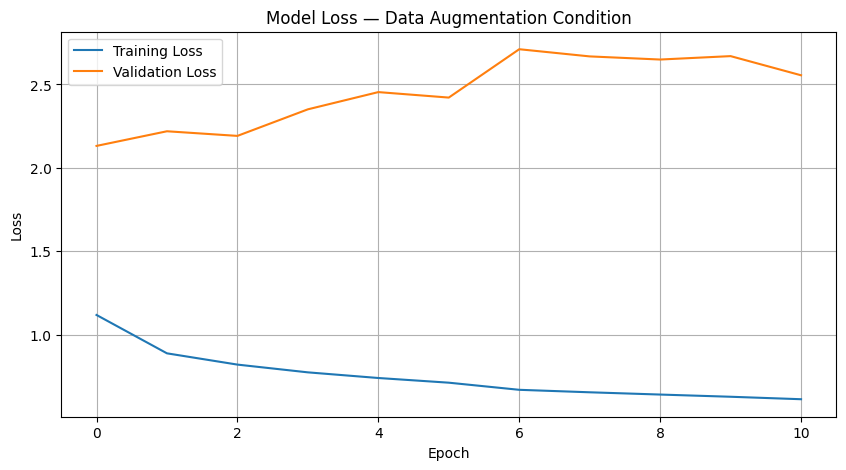

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss — Data Augmentation Condition')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

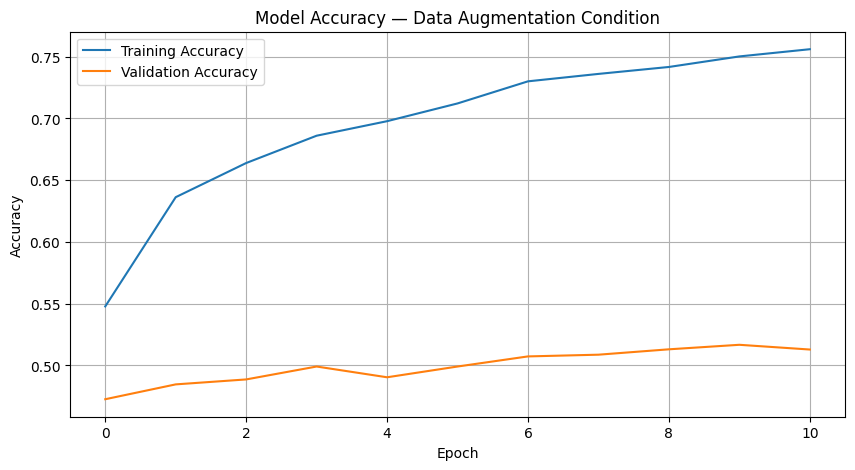

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy — Data Augmentation Condition')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Model evaluation

### Load saved model (use in a fresh session)

In [45]:
# aug_model = load_model('aug_best_model.keras')

In [46]:
loss, accuracy = aug_model.evaluate(test_generator)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

449/449 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.2317 - loss: 3.1526
Test Loss:     2.1727
Test Accuracy: 0.3780


In [47]:
predictions = aug_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

from sklearn.metrics import classification_report
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step
              precision    recall  f1-score   support

       angry       0.21      0.11      0.14       958
     disgust       0.40      0.02      0.03       111
        fear       0.16      0.01      0.02      1024
       happy       0.52      0.65      0.58      1774
     neutral       0.46      0.13      0.20      1233
         sad       0.26      0.64      0.37      1247
    surprise       0.47      0.59      0.52       831

    accuracy                           0.38      7178
   macro avg       0.36      0.31      0.27      7178
weighted avg       0.37      0.38      0.33      7178



Macro F1 Score: 0.2675


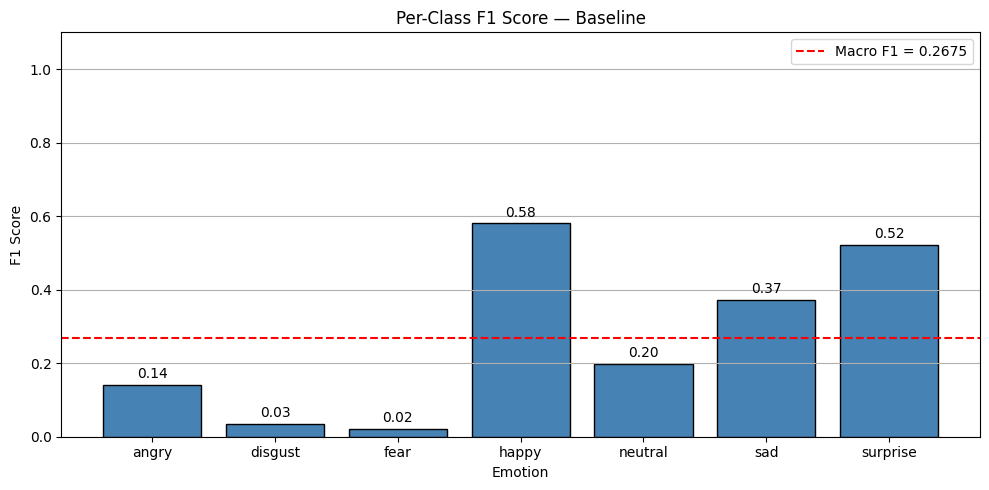

In [48]:

from sklearn.metrics import f1_score

# Macro F1 — single number summary
macro_f1 = f1_score(true_classes, predicted_classes, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

# Per-class F1 visualization
report = classification_report(
    true_classes, 
    predicted_classes,
    target_names=class_labels, 
    output_dict=True)

per_class_f1 = [report[cls]['f1-score'] for cls in class_labels]

plt.figure(figsize=(10, 5))
bars = plt.bar(class_labels, per_class_f1, color='steelblue', edgecolor='black')
plt.axhline(y=macro_f1, color='red', linestyle='--', label=f'Macro F1 = {macro_f1:.4f}')
for bar, val in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)
plt.title('Per-Class F1 Score — Baseline')
plt.xlabel('Emotion')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

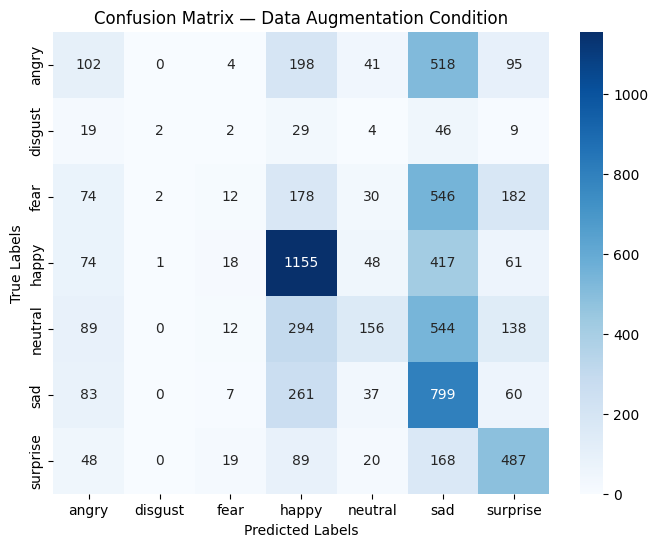

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix — Data Augmentation Condition')
plt.show()